In [2]:
import pandas as pd
import numpy as np
import openpyxl

In [3]:
df = pd.read_excel('../data/raw/Base_Case_Modelagem2.xlsx', sheet_name='Base de Treino')

df.head(5)

,ID,PERFORMANCE (var resposta),V1,V2,V3,V4,V5,V6,V7,V8,...,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19
0,1,0.0,563.101990,B,12.0,6.0,1264.109985,1.67665,944.123108,0.03750,...,10.0,353.0,Fiel,Fiel,Fiel,0.0,1.0,Premium,0.74687,49
1,9,NaN,190.110001,M,365.0,0.0,0.000000,0.00000,0.000000,0.02994,...,92.0,349.0,Inativo,Inativo,Inativo,1.0,1.0,Inativo,0.00000,55
2,52,0.0,283.477509,G,15.0,2.0,408.279999,1.12000,317.494812,NaN,...,72.0,173.0,Inativo,Ausente,Ocasional,0.0,1.0,Inativo,0.77764,46
3,63,NaN,80.919998,G,83.0,0.0,0.000000,0.00000,0.000000,NaN,...,92.0,118.0,Inativo,Inativo,Novo,-1.0,1.0,Inativo,0.00000,59
4,105,0.0,492.380005,M,365.0,1.0,0.000000,0.00000,0.000000,NaN,...,65.0,318.0,Inativo,Ausente,Inativo,-1.0,1.0,Inativo,0.00000,64


Variáveis V12, V13, V17 são categóricas

In [4]:
df.tail()

,ID,PERFORMANCE (var resposta),V1,V2,V3,V4,V5,V6,V7,V8,...,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19
35567,676588,NaN,95.699997,G,365.0,0.0,0.00000,0.00000,0.000000,NaN,...,92.0,324.0,Inativo,Inativo,Inativo,1.0,1.0,Inativo,0.00000,52
35568,676613,1.0,191.145004,B,365.0,2.0,0.00000,0.00000,0.000000,NaN,...,7.0,344.0,Ocasional,Ocasional,Inativo,0.0,1.0,Premium,0.00000,30
35569,676658,0.0,79.314713,W,365.0,5.0,382.76001,3.03185,240.470062,NaN,...,11.0,395.0,Fiel,Fiel,Fiel,0.0,1.0,Premium,0.62825,29
35570,676659,0.0,286.664001,B,12.0,3.0,423.75000,0.82353,236.076233,NaN,...,9.0,325.0,Fiel,Ocasional,Ausente,0.0,1.0,Premium,0.55711,60
35571,676660,0.0,155.020004,M,365.0,0.0,0.00000,0.00000,0.000000,NaN,...,92.0,335.0,Inativo,Inativo,Inativo,0.0,1.0,Inativo,0.00000,21


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35572 entries, 0 to 35571
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          35572 non-null  int64  
 1   PERFORMANCE (var resposta)  18745 non-null  float64
 2   V1                          34922 non-null  float64
 3   V2                          33182 non-null  object 
 4   V3                          33861 non-null  float64
 5   V4                          35540 non-null  float64
 6   V5                          34922 non-null  float64
 7   V6                          34922 non-null  float64
 8   V7                          34922 non-null  float64
 9   V8                          14144 non-null  float64
 10  V9                          32909 non-null  float64
 11  V10                         35540 non-null  float64
 12  V11                         35540 non-null  float64
 13  V12                         355

In [6]:
print("Número de linhas e colunas:", df.shape)

Número de linhas e colunas: (35572, 21)


In [7]:
df.describe()

,ID,PERFORMANCE (var resposta),V1,V3,V4,V5,V6,V7,V8,V9,V10,V11,V15,V16,V18,V19
count,35572.000000,18745.000000,34922.000000,33861.000000,35540.000000,34922.000000,34922.000000,34922.000000,14144.000000,32909.000000,35540.000000,35540.000000,34922.000000,35447.000000,34922.000000,35572.000000
mean,337615.796666,0.199467,245.632589,254.491893,5.167276,536.066752,1.855144,335.295699,0.055143,0.068210,38.197777,281.386860,0.125594,0.943775,0.418571,47.616665
std,195957.367514,0.399610,272.205288,159.927435,7.586663,774.517872,2.484477,486.231000,0.079842,0.106627,36.958412,126.682322,0.626102,0.230359,0.358214,35.555455
min,1.000000,0.000000,0.750000,1.000000,0.000000,0.000000,0.000000,0.000000,-0.002420,-0.057570,0.000000,0.000000,-1.000000,0.000000,0.000000,-5943.000000
25%,169313.750000,0.000000,72.423143,50.000000,0.000000,0.000000,0.000000,0.000000,0.003858,-0.033890,5.000000,193.000000,0.000000,1.000000,0.000000,36.000000
50%,336772.500000,0.000000,152.281250,365.000000,2.000000,308.779999,1.195120,168.661179,0.023450,0.054650,20.000000,325.000000,0.000000,1.000000,0.481060,47.000000
75%,508681.500000,0.000000,323.497498,365.000000,7.000000,814.459991,2.512820,501.991646,0.069753,0.162070,92.000000,355.000000,1.000000,1.000000,0.669063,59.000000
max,676660.000000,1.000000,5716.069824,365.000000,84.000000,25991.000000,26.000000,11353.650391,0.392630,0.329520,92.000000,536.000000,1.000000,1.000000,2.157450,110.000000


In [8]:
df.isnull().sum()

(df.isnull().mean()*100).sort_values(ascending=False)

V8                            60.238390
PERFORMANCE (var resposta)    47.304059
V9                             7.486225
V2                             6.718768
V14                            6.589452
V3                             4.809963
V13                            2.307995
V18                            1.827280
V1                             1.827280
V7                             1.827280
V15                            1.827280
V5                             1.827280
V6                             1.827280
V16                            0.351400
V11                            0.089958
V4                             0.089958
V10                            0.089958
V17                            0.089958
V12                            0.089958
ID                             0.000000
V19                            0.000000
dtype: float64

Observação: Observa-se que quase todas as variáveis são numéricas, o que é bom nesse caso!!
Todavia, há uma quantidade considerável de nulo nas colunas, incluindo a variável de resposta.

## Verificação de balanceamento da váriavel

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8,5)

In [11]:
df['PERFORMANCE (var resposta)'].value_counts(normalize=True) * 100

PERFORMANCE (var resposta)
0.0    80.053348
1.0    19.946652
Name: proportion, dtype: float64

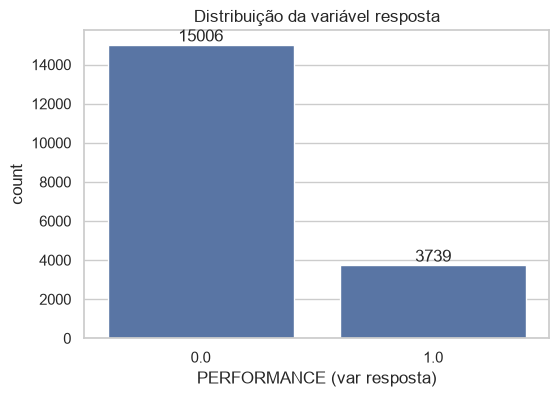

In [12]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x='PERFORMANCE (var resposta)'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribuição da variável resposta")

plt.show()

## Convertendo variáveis textuais para numéricas

Variáveis V12, V13, V17 são categóricas

In [13]:
df['V12'].value_counts(normalize=True) * 100

V12
Fiel         39.189645
Inativo      30.264491
Ausente      12.549240
Ocasional     9.521666
Novo          8.474958
Name: proportion, dtype: float64

In [14]:
df['V13'].value_counts(normalize=True) * 100

V13
Fiel         45.095105
Inativo      29.791948
Ausente      11.205433
Ocasional    10.805444
Novo          3.102069
Name: proportion, dtype: float64

In [15]:
df['V17'].value_counts(normalize=True) * 100

V17
Inativo         30.264491
Premium         29.243106
Ausente         12.549240
Conveniencia    11.586944
Ativo            6.868317
Economico        4.766460
Basico           3.114800
Novo             1.606640
Name: proportion, dtype: float64

## Distribuição das variáveis numéricas

In [16]:
numeric_columns = df.select_dtypes(include=np.number).columns.drop(['PERFORMANCE (var resposta)', 'ID'])

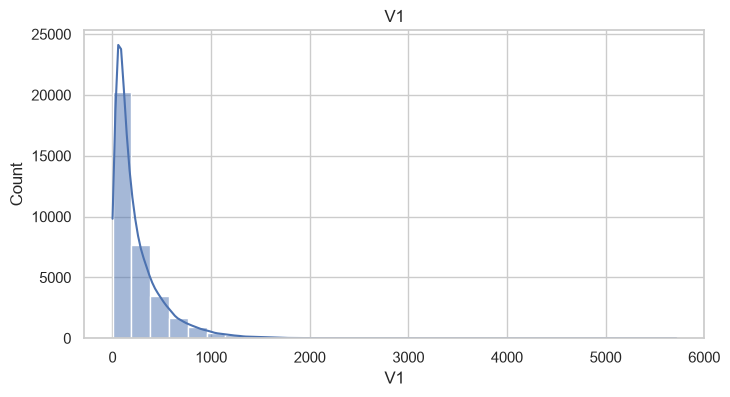

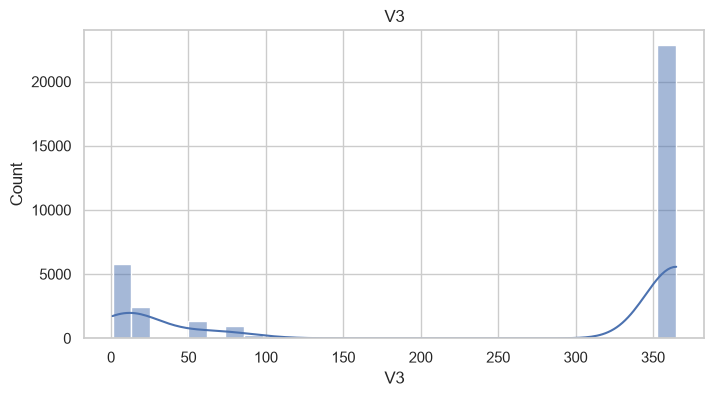

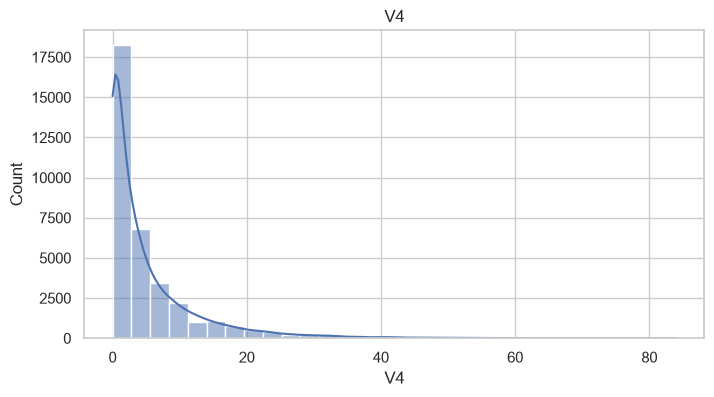

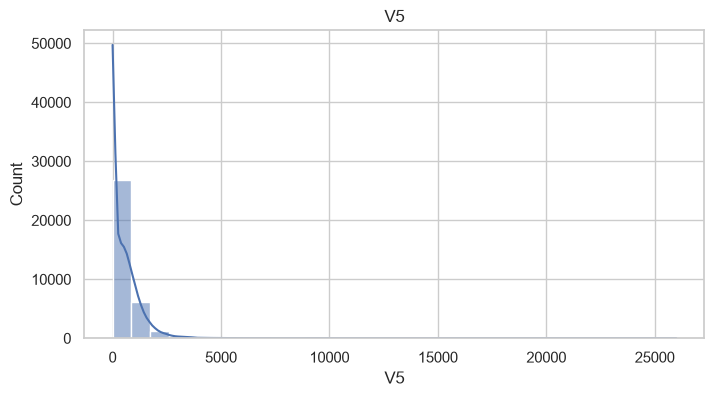

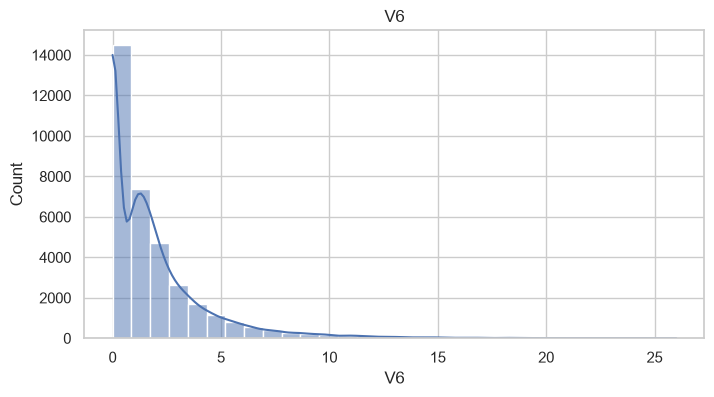

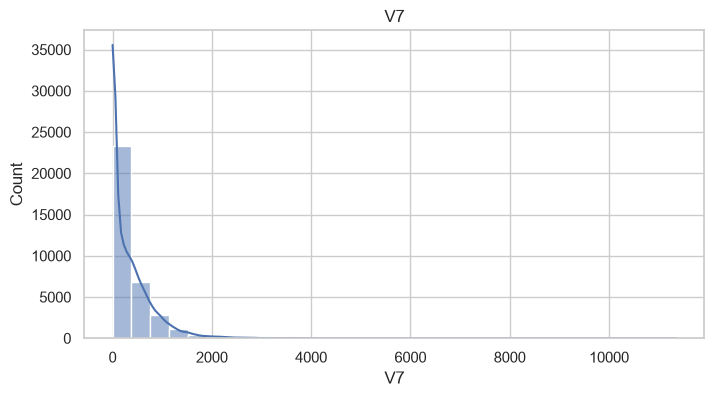

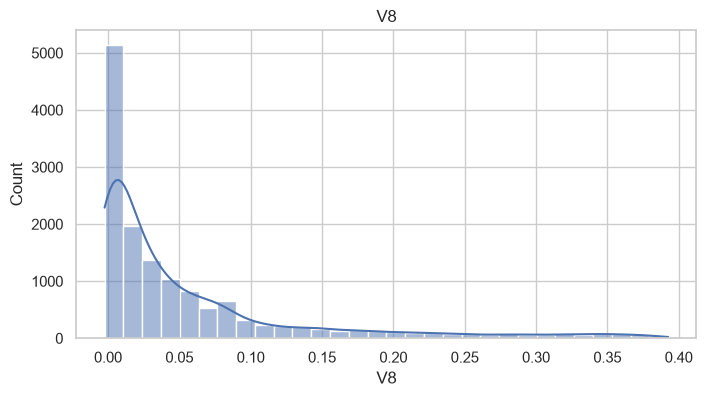

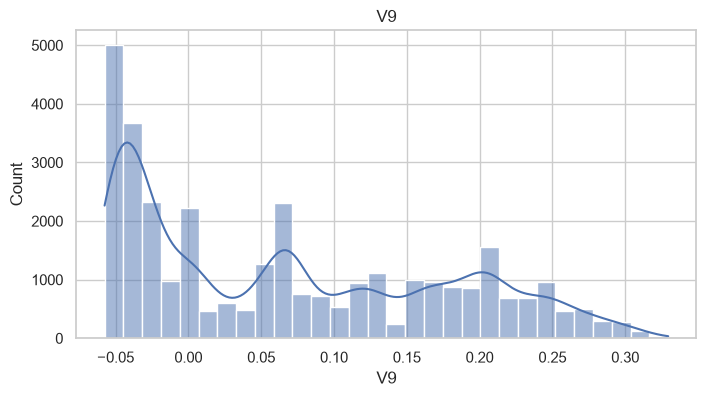

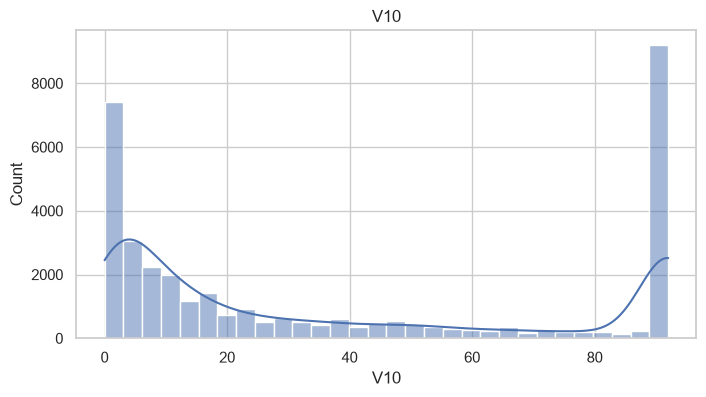

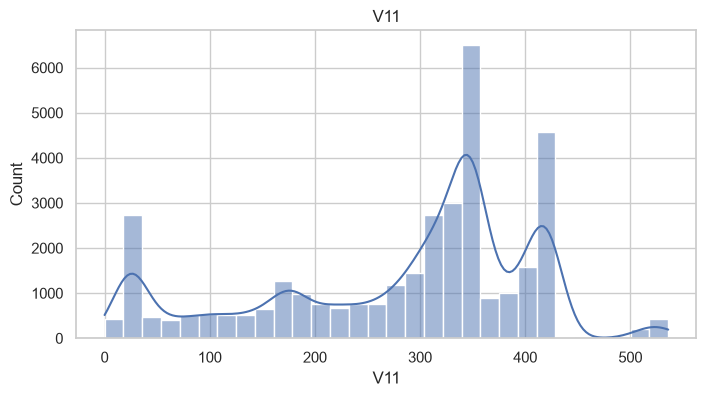

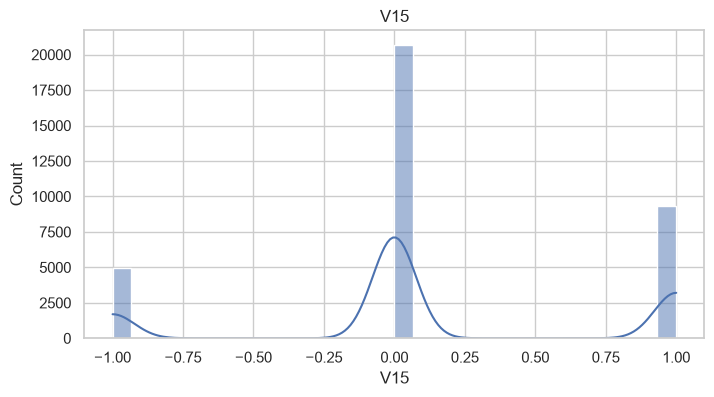

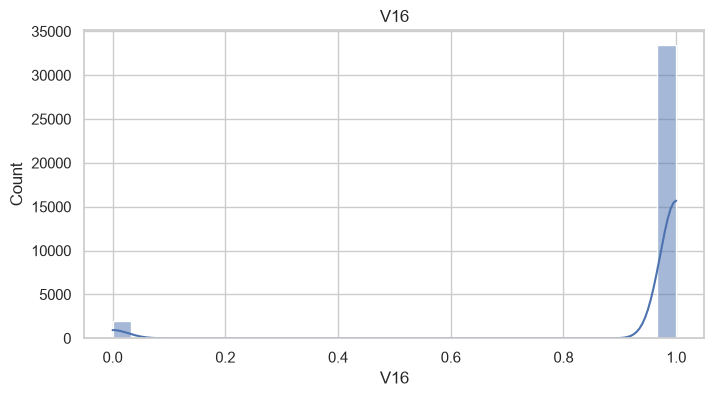

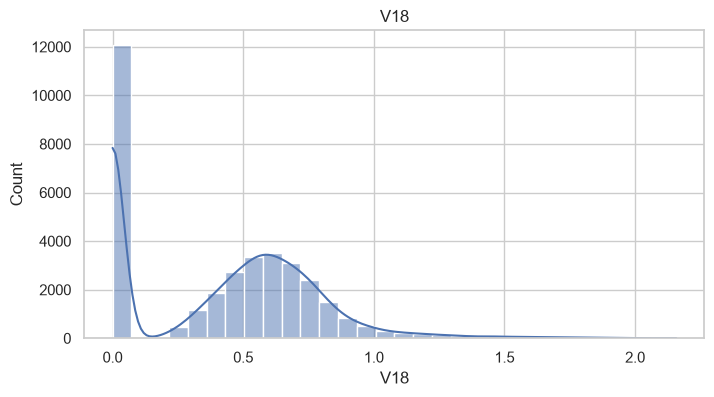

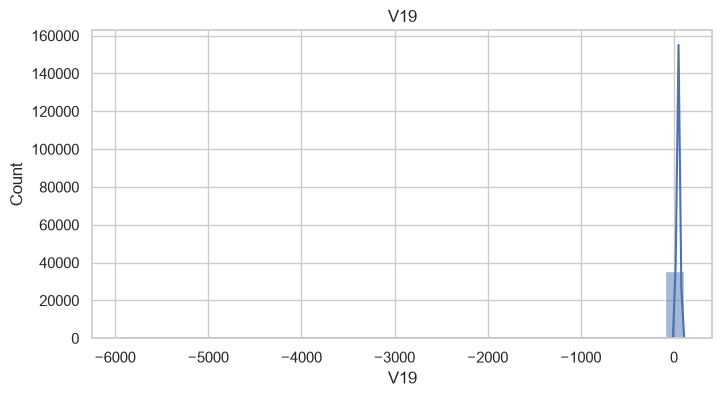

In [17]:
for column in numeric_columns:

    plt.figure(figsize=(8,4))

    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True
    )

    plt.title(column)

    plt.show()

## Outliers

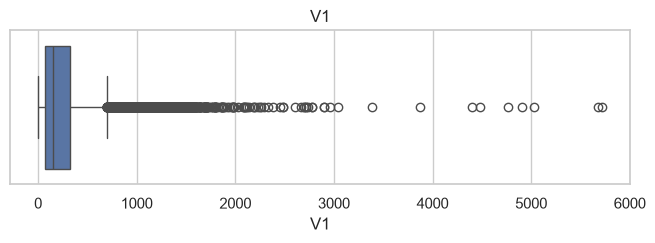

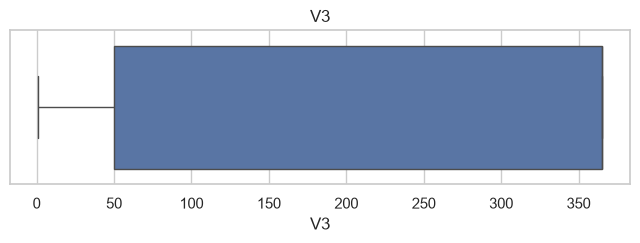

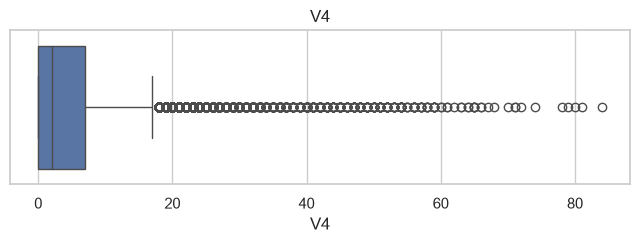

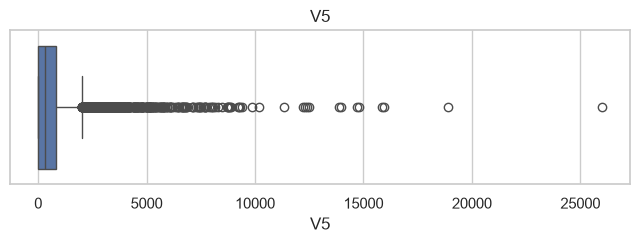

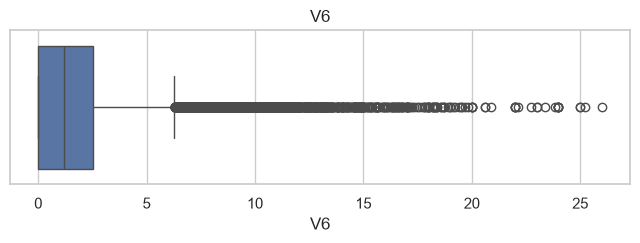

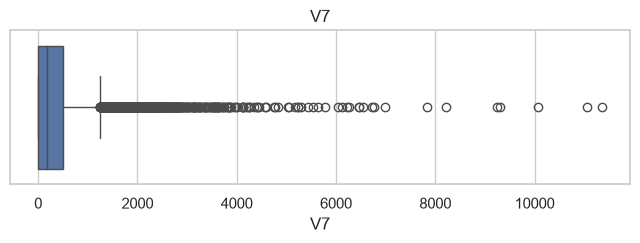

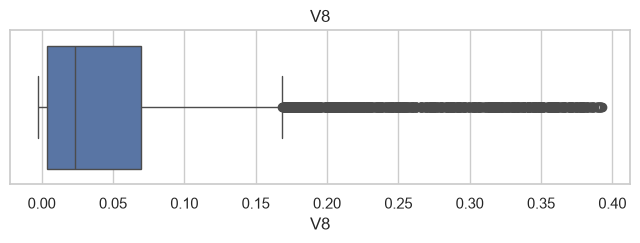

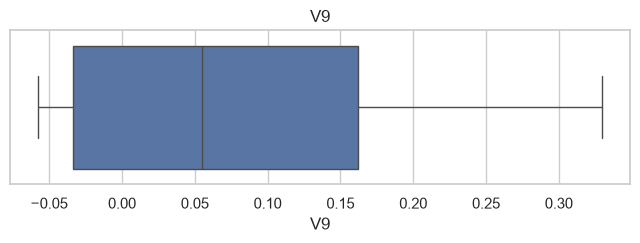

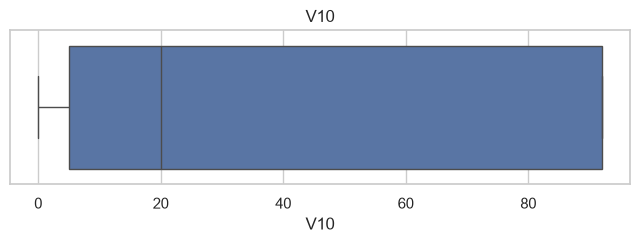

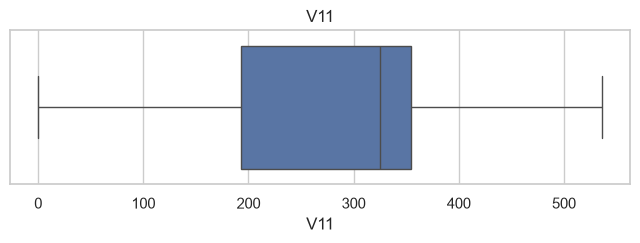

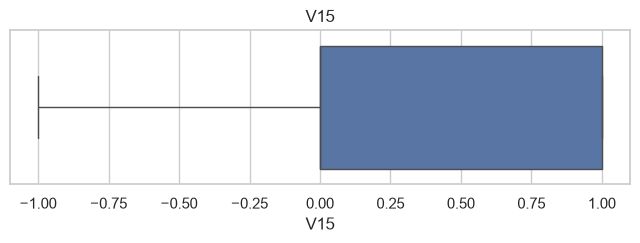

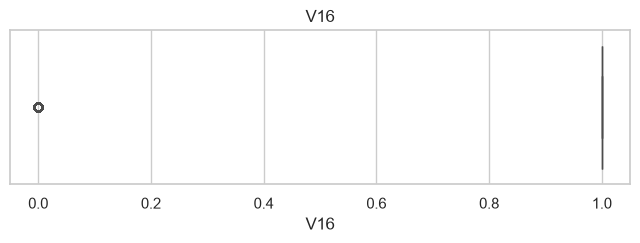

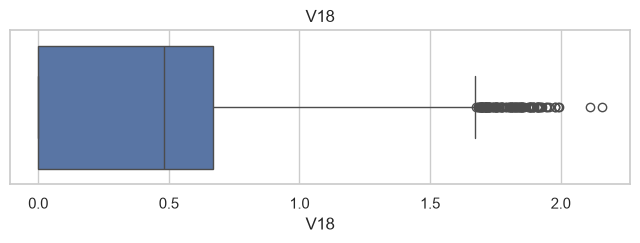

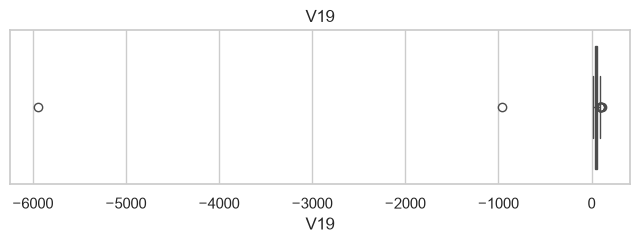

In [18]:
for column in numeric_columns:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[column]
    )

    plt.title(column)

    plt.show()

In [19]:
corr = df.corr(numeric_only=True)

In [20]:
corr['PERFORMANCE (var resposta)'].sort_values(ascending=False).drop('ID')

PERFORMANCE (var resposta)    1.000000
V10                           0.180440
V3                            0.064955
V15                          -0.016410
V11                          -0.039910
V16                          -0.048682
V19                          -0.059641
V6                           -0.066476
V8                           -0.073111
V1                           -0.075339
V4                           -0.079390
V9                           -0.083296
V5                           -0.113540
V18                          -0.115076
V7                           -0.117396
Name: PERFORMANCE (var resposta), dtype: float64

In [21]:
pd.crosstab(
    df['V12'],
    df['PERFORMANCE (var resposta)'],
    normalize='index'
) * 100

PERFORMANCE (var resposta),0.0,1.0
V12,,
Ausente,79.124028,20.875972
Fiel,87.584854,12.415146
Inativo,70.824018,29.175982
Novo,82.932692,17.067308
Ocasional,83.333333,16.666667


In [22]:
pd.crosstab(
    df['V13'],
    df['PERFORMANCE (var resposta)'],
    normalize='index'
) * 100

PERFORMANCE (var resposta),0.0,1.0
V13,,
Ausente,80.780347,19.219653
Fiel,86.471057,13.528943
Inativo,71.124222,28.875778
Novo,78.547297,21.452703
Ocasional,83.633556,16.366444


In [23]:
pd.crosstab(
    df['V17'],
    df['PERFORMANCE (var resposta)'],
    normalize='index'
) * 100

PERFORMANCE (var resposta),0.0,1.0
V17,,
Ativo,85.138340,14.861660
Ausente,79.124028,20.875972
Basico,88.128773,11.871227
Conveniencia,80.188679,19.811321
Economico,81.157635,18.842365
Inativo,70.824018,29.175982
Novo,75.939850,24.060150
Premium,89.863813,10.136187


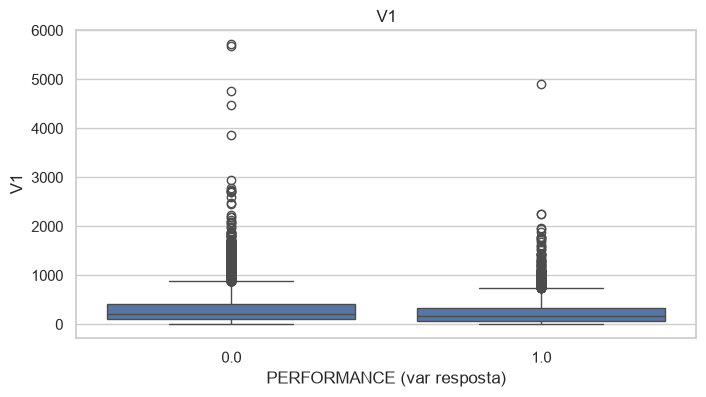

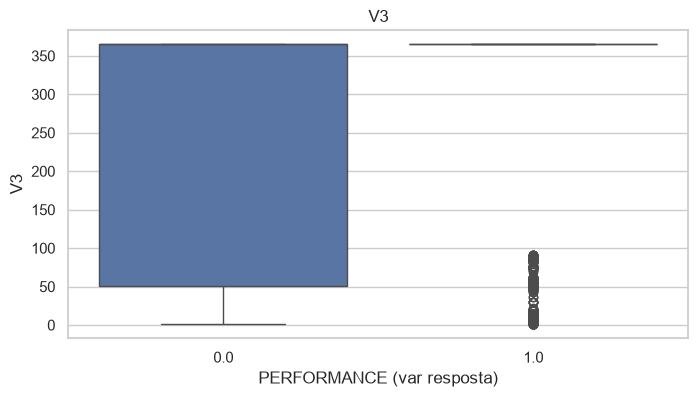

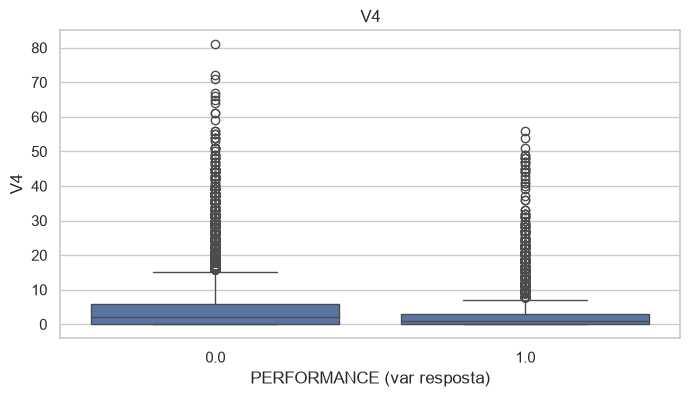

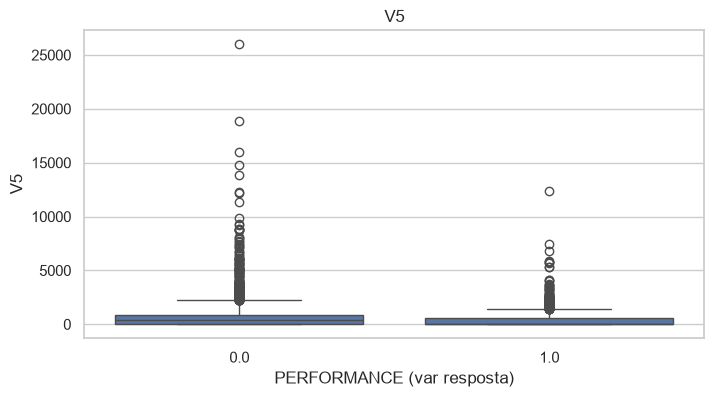

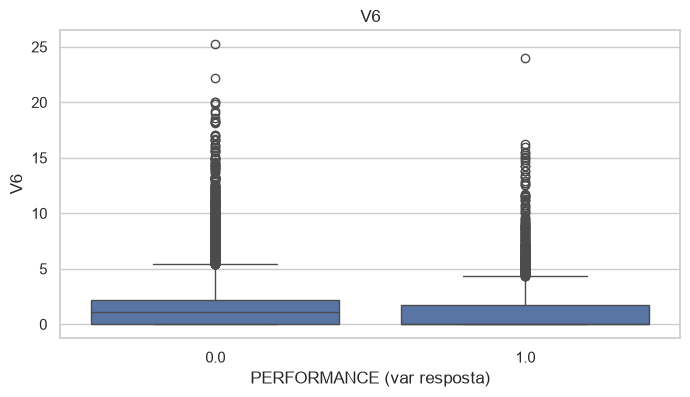

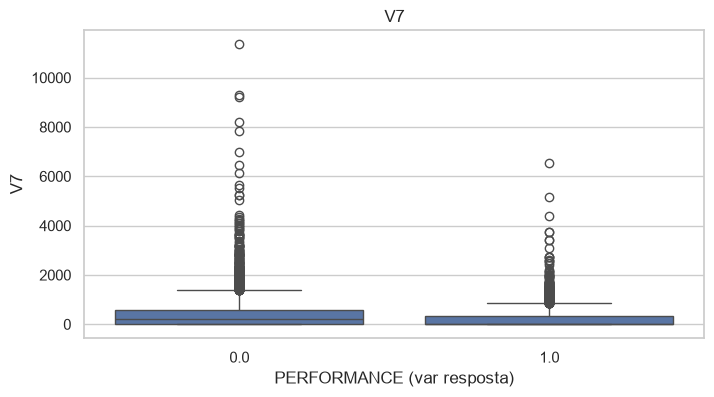

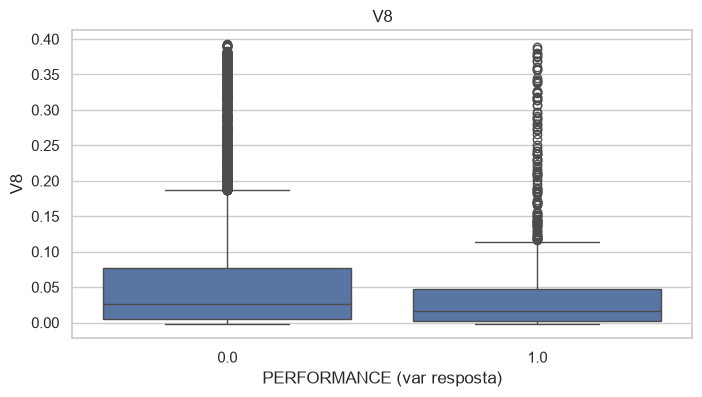

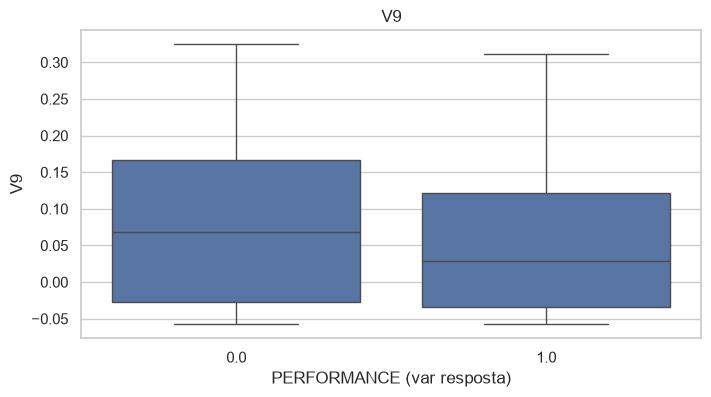

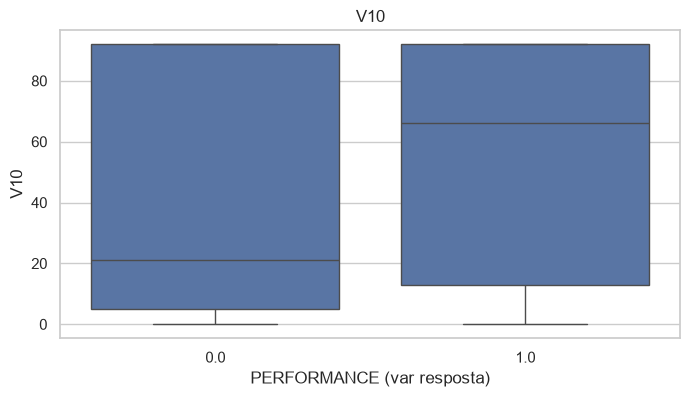

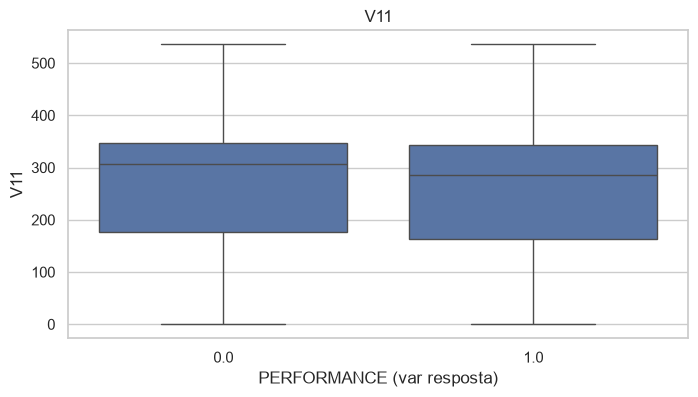

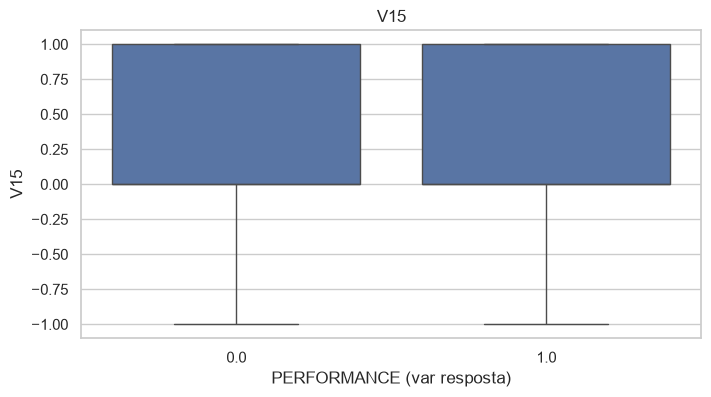

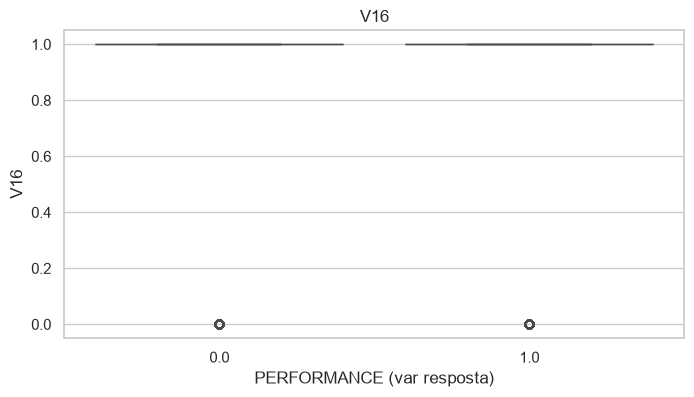

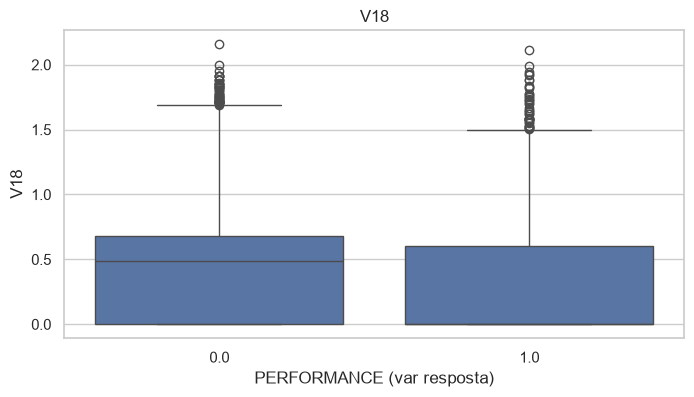

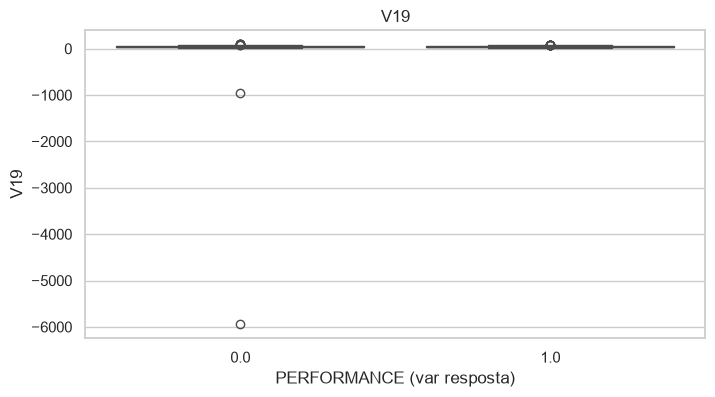

In [26]:
for column in numeric_columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=df,
        x='PERFORMANCE (var resposta)',
        y=column
    )

    plt.title(column)

    plt.show()